In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate

In [2]:
my_data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Code/Final_DataFrame_2016_2024_Weather_Kwh.csv", index_col= "time", parse_dates= True)
my_data.tail()

,Unnamed: 0,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,cloudcover,shortwave_radiation,precipitation,snowfall,windspeed_10m,...,snowfall.4,windspeed_10m.4,windgusts_10m.4,winddirection_10m.4,evapotranspiration.4,soil_temperature_0cm.4,soil_moisture_0_1cm.4,weathercode.4,city.4,Kwh
time,,,,,,,,,,,,,,,,,,,,,
2024-04-07 19:00:00,72475,17.8,54,8.3,936.0,60,187.0,0.0,0.0,9.8,...,0.0,9.1,24.1,187,NaN,NaN,NaN,51,Elassona,0.0007
2024-04-07 20:00:00,72476,15.3,67,9.2,936.2,37,38.0,0.0,0.0,4.8,...,0.0,5.6,24.5,207,NaN,NaN,NaN,2,Elassona,0.0000
2024-04-07 21:00:00,72477,12.7,79,9.1,936.2,8,0.0,0.0,0.0,7.6,...,0.0,3.6,16.2,225,NaN,NaN,NaN,1,Elassona,0.0000
2024-04-07 22:00:00,72478,14.7,68,8.7,937.6,2,0.0,0.0,0.0,5.9,...,0.0,4.9,11.5,216,NaN,NaN,NaN,0,Elassona,0.0000
2024-04-07 23:00:00,72479,11.8,79,8.4,937.4,20,0.0,0.0,0.0,5.8,...,0.0,4.1,11.2,232,NaN,NaN,NaN,0,Elassona,0.0000


In [3]:
my_data.describe()

,Unnamed: 0,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,cloudcover,shortwave_radiation,precipitation,snowfall,windspeed_10m,...,precipitation.4,snowfall.4,windspeed_10m.4,windgusts_10m.4,winddirection_10m.4,evapotranspiration.4,soil_temperature_0cm.4,soil_moisture_0_1cm.4,weathercode.4,Kwh
count,72480.000000,72480.000000,72480.000000,72480.000000,72480.000000,72480.000000,72480.000000,72480.000000,72480.000000,72480.000000,...,72480.000000,72480.000000,72480.000000,72480.000000,72480.000000,0.0,0.0,0.0,72480.000000,72480.000000
mean,36239.500000,12.763849,63.466460,5.154531,933.532512,42.602649,187.000731,0.075777,0.004453,6.802764,...,0.073045,0.001581,5.375735,17.352486,168.146482,NaN,NaN,NaN,6.918212,0.147063
std,20923.318093,8.689977,18.953605,6.522748,5.676751,40.059390,261.395173,0.375592,0.057674,4.637831,...,0.396263,0.039844,3.119870,9.178496,119.936332,NaN,NaN,NaN,16.772329,0.220532
min,0.000000,-14.300000,11.000000,-22.500000,901.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.500000,1.000000,NaN,NaN,NaN,0.000000,0.000000
25%,18119.750000,6.000000,49.000000,1.100000,930.200000,1.000000,0.000000,0.000000,0.000000,3.300000,...,0.000000,0.000000,3.200000,10.100000,36.000000,NaN,NaN,NaN,0.000000,0.000000
50%,36239.500000,12.300000,64.000000,5.700000,933.900000,31.000000,9.000000,0.000000,0.000000,5.600000,...,0.000000,0.000000,4.700000,15.100000,174.000000,NaN,NaN,NaN,1.000000,0.000100
75%,54359.250000,19.300000,79.000000,10.300000,937.200000,89.000000,343.000000,0.000000,0.000000,9.100000,...,0.000000,0.000000,6.800000,22.700000,274.000000,NaN,NaN,NaN,3.000000,0.258625
max,72479.000000,38.000000,100.000000,22.000000,954.200000,100.000000,990.000000,24.000000,3.150000,33.700000,...,17.200000,4.690000,28.200000,86.400000,360.000000,NaN,NaN,NaN,75.000000,0.868400


In [4]:
my_data = my_data.drop(my_data.columns[0], axis= 1)
my_data.head()

,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,cloudcover,shortwave_radiation,precipitation,snowfall,windspeed_10m,windgusts_10m,...,snowfall.4,windspeed_10m.4,windgusts_10m.4,winddirection_10m.4,evapotranspiration.4,soil_temperature_0cm.4,soil_moisture_0_1cm.4,weathercode.4,city.4,Kwh
time,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,-4.1,45,-14.3,942.0,0,0.0,0.0,0.0,2.5,12.2,...,0.0,4.7,13.7,351,NaN,NaN,NaN,1,Elassona,0.0
2016-01-01 01:00:00,-4.2,45,-14.4,942.3,0,0.0,0.0,0.0,2.3,10.8,...,0.0,5.8,13.0,22,NaN,NaN,NaN,0,Elassona,0.0
2016-01-01 02:00:00,-4.4,46,-14.4,942.1,0,0.0,0.0,0.0,1.6,10.1,...,0.0,4.5,11.9,14,NaN,NaN,NaN,1,Elassona,0.0
2016-01-01 03:00:00,-4.5,46,-14.4,941.8,0,0.0,0.0,0.0,1.8,9.7,...,0.0,4.0,12.6,360,NaN,NaN,NaN,3,Elassona,0.0
2016-01-01 04:00:00,-5.2,46,-15.0,941.4,0,0.0,0.0,0.0,1.6,10.1,...,0.0,4.0,13.7,333,NaN,NaN,NaN,3,Elassona,0.0


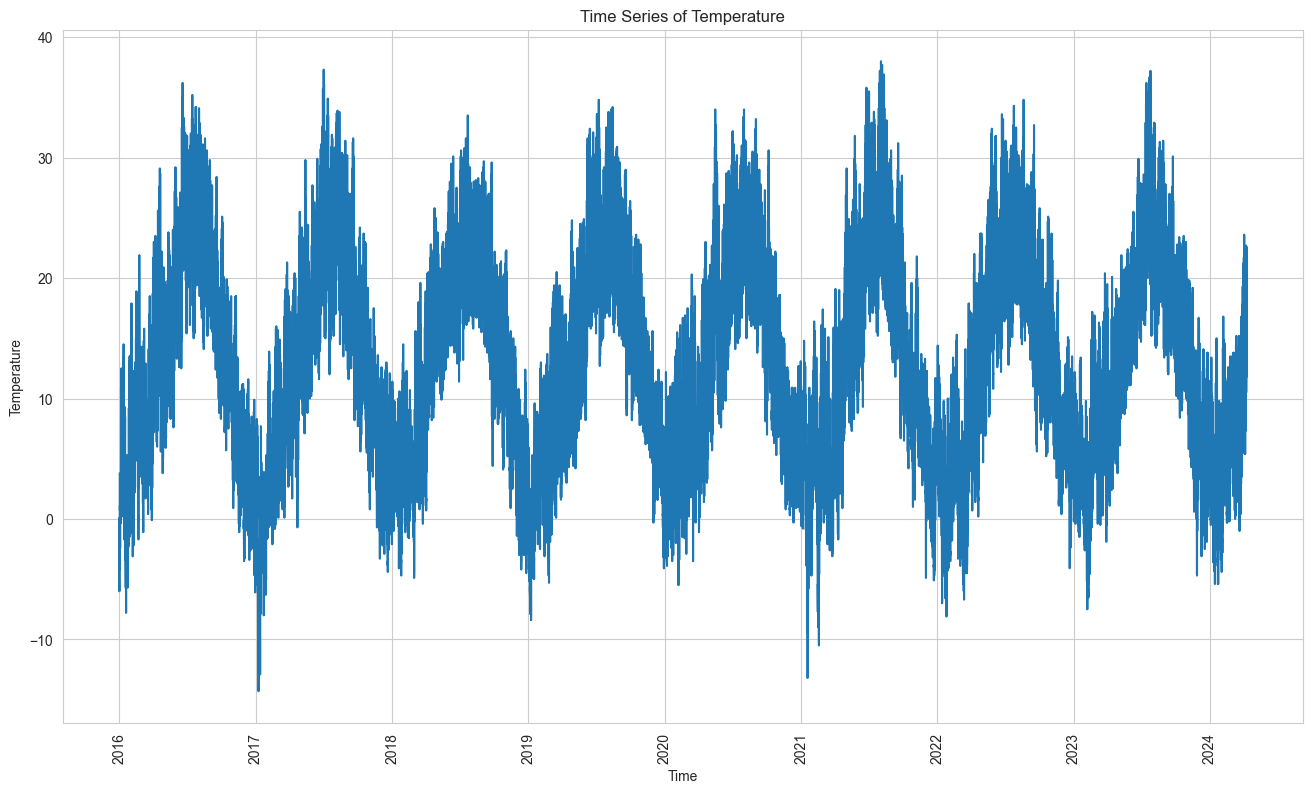

In [5]:
sns.set_style("whitegrid")
plt.figure(figsize= (16, 9))
sns.lineplot(x = my_data.index, y = my_data["temperature_2m"], markers= "o")
plt.title("Time Series of Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.xticks(rotation = 90)
plt.show()

In [6]:
pd.set_option('display.max_rows', None)


my_data.isna().sum()

temperature_2m                0
relative_humidity_2m          0
dew_point_2m                  0
surface_pressure              0
cloudcover                    0
shortwave_radiation           0
precipitation                 0
snowfall                      0
windspeed_10m                 0
windgusts_10m                 0
winddirection_10m             0
evapotranspiration        72480
soil_temperature_0cm      72480
soil_moisture_0_1cm       72480
weathercode                   0
city                          0
temperature_2m.1              0
relative_humidity_2m.1        0
dew_point_2m.1                0
surface_pressure.1            0
cloudcover.1                  0
shortwave_radiation.1         0
precipitation.1               0
snowfall.1                    0
windspeed_10m.1               0
windgusts_10m.1               0
winddirection_10m.1           0
evapotranspiration.1      72480
soil_temperature_0cm.1    72480
soil_moisture_0_1cm.1     72480
weathercode.1                 0
city.1  

In [7]:
my_data[my_data["temperature_2m.1"].isna()]

,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,cloudcover,shortwave_radiation,precipitation,snowfall,windspeed_10m,windgusts_10m,...,snowfall.4,windspeed_10m.4,windgusts_10m.4,winddirection_10m.4,evapotranspiration.4,soil_temperature_0cm.4,soil_moisture_0_1cm.4,weathercode.4,city.4,Kwh
time,,,,,,,,,,,,,,,,,,,,,


In [8]:
pd.set_option('display.max_columns', None)


my_data = my_data.dropna(axis= 1)
my_data.head(30)

,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,cloudcover,shortwave_radiation,precipitation,snowfall,windspeed_10m,windgusts_10m,winddirection_10m,weathercode,city,temperature_2m.1,relative_humidity_2m.1,dew_point_2m.1,surface_pressure.1,cloudcover.1,shortwave_radiation.1,precipitation.1,snowfall.1,windspeed_10m.1,windgusts_10m.1,winddirection_10m.1,weathercode.1,city.1,temperature_2m.2,relative_humidity_2m.2,dew_point_2m.2,surface_pressure.2,cloudcover.2,shortwave_radiation.2,precipitation.2,snowfall.2,windspeed_10m.2,windgusts_10m.2,winddirection_10m.2,weathercode.2,city.2,temperature_2m.3,relative_humidity_2m.3,dew_point_2m.3,surface_pressure.3,cloudcover.3,shortwave_radiation.3,precipitation.3,snowfall.3,windspeed_10m.3,windgusts_10m.3,winddirection_10m.3,weathercode.3,city.3,temperature_2m.4,relative_humidity_2m.4,dew_point_2m.4,surface_pressure.4,cloudcover.4,shortwave_radiation.4,precipitation.4,snowfall.4,windspeed_10m.4,windgusts_10m.4,winddirection_10m.4,weathercode.4,city.4,Kwh
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,-4.1,45,-14.3,942.0,0,0.0,0.0,0.0,2.5,12.2,360,0,Kozani,-2.1,43,-12.9,1011.1,0,0.0,0.0,0.0,4.1,11.2,322,0,Veria,-5.9,42,-16.9,948.3,0,0.0,0.0,0.0,3.2,17.3,360,0,Florina,-3.5,36,-16.3,960.4,77,0.0,0.0,0.07,1.9,8.3,338,71,Grevena,-0.9,75,-4.7,995.3,29,0.0,0.0,0.0,4.7,13.7,351,1,Elassona,0.0000
2016-01-01 01:00:00,-4.2,45,-14.4,942.3,0,0.0,0.0,0.0,2.3,10.8,51,0,Kozani,-1.9,41,-13.5,1011.8,0,0.0,0.0,0.0,2.9,11.2,330,0,Veria,-5.1,39,-17.1,949.1,0,0.0,0.0,0.0,3.6,16.6,6,0,Florina,-3.6,36,-16.6,960.3,71,0.0,0.0,0.00,2.1,8.3,31,2,Grevena,-1.1,74,-5.1,995.7,7,0.0,0.0,0.0,5.8,13.0,22,0,Elassona,0.0000
2016-01-01 02:00:00,-4.4,46,-14.4,942.1,0,0.0,0.0,0.0,1.6,10.1,27,0,Kozani,-2.0,40,-13.9,1011.5,0,0.0,0.0,0.0,4.6,11.2,342,0,Veria,-5.0,38,-17.1,948.7,0,0.0,0.0,0.0,2.6,15.8,344,0,Florina,-3.7,35,-16.8,960.0,75,0.0,0.0,0.00,2.7,7.9,23,2,Grevena,-1.3,74,-5.4,995.3,47,0.0,0.0,0.0,4.5,11.9,14,1,Elassona,0.0000
2016-01-01 03:00:00,-4.5,46,-14.4,941.8,0,0.0,0.0,0.0,1.8,9.7,360,0,Kozani,-2.3,39,-14.4,1011.1,0,0.0,0.0,0.0,3.1,10.8,339,0,Veria,-5.1,38,-17.2,948.3,0,0.0,0.0,0.0,2.3,14.8,321,0,Florina,-3.8,35,-17.1,959.8,82,0.0,0.0,0.00,3.1,8.6,21,3,Grevena,-1.5,72,-5.9,994.9,89,0.0,0.0,0.0,4.0,12.6,360,3,Elassona,0.0000
2016-01-01 04:00:00,-5.2,46,-15.0,941.4,0,0.0,0.0,0.0,1.6,10.1,333,0,Kozani,-3.9,41,-15.2,1010.8,0,0.0,0.0,0.0,2.9,11.2,7,0,Veria,-5.9,38,-18.1,947.9,0,0.0,0.0,0.0,2.0,14.0,315,0,Florina,-4.7,34,-18.0,959.4,80,0.0,0.0,0.00,3.8,9.7,17,3,Grevena,-2.9,70,-7.7,994.7,98,0.0,0.0,0.0,4.0,13.7,333,3,Elassona,0.0000
2016-01-01 05:00:00,-5.3,46,-15.2,941.1,2,0.0,0.0,0.0,1.8,10.4,349,0,Kozani,-4.2,41,-15.4,1010.6,0,0.0,0.0,0.0,3.3,10.8,13,0,Veria,-5.9,37,-18.2,947.6,0,0.0,0.0,0.0,2.0,13.7,315,0,Florina,-4.7,34,-18.1,959.1,74,0.0,0.0,0.00,4.1,11.5,15,2,Grevena,-3.1,68,-8.2,994.2,98,0.0,0.0,0.0,4.7,14.4,328,3,Elassona,0.0000
2016-01-01 06:00:00,-5.4,45,-15.3,941.1,0,0.0,0.0,0.0,1.6,11.2,27,0,Kozani,-4.2,41,-15.6,1010.6,0,0.0,0.0,0.0,3.2,10.4,27,0,Veria,-5.9,37,-18.2,947.5,0,0.0,0.0,0.0,1.6,14.0,333,0,Florina,-4.7,34,-18.3,959.2,71,0.0,0.0,0.00,4.6,13.0,18,2,Grevena,-3.2,64,-8.9,994.3,93,0.0,0.0,0.0,5.0,14.8,330,3,Elassona,0.0000
2016-01-01 07:00:00,-5.5,45,-15.6,940.9,1,0.0,0.0,0.0,0.7,10.8,90,0,Kozani,-4.2,40,-15.7,1010.4,0,0.0,0.0,0.0,3.1,10.4,45,0,Veria,-5.9,37,-18.3,947.3,0,0.0,0.0,0.0,1.3,14.0,326,0,Florina,-4.7,34,-18.3,959.0,66,0.0,0.0,0.00,3.5,13.0,24,2,Grevena,-3.3,62,-9.6,994.1,92,0.0,0.0,0.0,4.6,14.4,321,3,Elassona,0.0000
2016-01-01 08:00:00,-5.5,44,-15.8,941.3,1,0.0,0.0,0.0,1.0,10.8,135,0,Kozani,-4.2,40,-15.8,1010.7,0,0.0,0.0,0.0,2.6,10.1,56,0,Veria,-5.8,37,-18.2,947.5,0,0.0,0.0,0.0,1.5,14.0,315,0,Florina,-4.6,33,-18.4,959.4,62,0.0,0.0,0.00,3.2,12.2,27,2,Grevena,-3.4,58,-10.4,994.4,93,0.0,0.0,0.0,4.6,13.3,315,3,Elassona,0.0000


In [9]:
my_data.tail()

,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,cloudcover,shortwave_radiation,precipitation,snowfall,windspeed_10m,windgusts_10m,winddirection_10m,weathercode,city,temperature_2m.1,relative_humidity_2m.1,dew_point_2m.1,surface_pressure.1,cloudcover.1,shortwave_radiation.1,precipitation.1,snowfall.1,windspeed_10m.1,windgusts_10m.1,winddirection_10m.1,weathercode.1,city.1,temperature_2m.2,relative_humidity_2m.2,dew_point_2m.2,surface_pressure.2,cloudcover.2,shortwave_radiation.2,precipitation.2,snowfall.2,windspeed_10m.2,windgusts_10m.2,winddirection_10m.2,weathercode.2,city.2,temperature_2m.3,relative_humidity_2m.3,dew_point_2m.3,surface_pressure.3,cloudcover.3,shortwave_radiation.3,precipitation.3,snowfall.3,windspeed_10m.3,windgusts_10m.3,winddirection_10m.3,weathercode.3,city.3,temperature_2m.4,relative_humidity_2m.4,dew_point_2m.4,surface_pressure.4,cloudcover.4,shortwave_radiation.4,precipitation.4,snowfall.4,windspeed_10m.4,windgusts_10m.4,winddirection_10m.4,weathercode.4,city.4,Kwh
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-04-07 19:00:00,17.8,54,8.3,936.0,60,187.0,0.0,0.0,9.8,27.0,82,2,Kozani,19.6,66,13.1,1000.3,100,147.0,0.0,0.0,2.9,20.2,83,3,Veria,20.5,35,4.5,942.1,22,188.0,0.0,0.0,22.0,54.0,21,1,Florina,21.4,36,5.7,952.1,23,168.0,0.0,0.0,8.4,30.6,59,1,Grevena,19.5,59,11.2,985.2,84,139.0,0.1,0.0,9.1,24.1,187,51,Elassona,0.0007
2024-04-07 20:00:00,15.3,67,9.2,936.2,37,38.0,0.0,0.0,4.8,22.0,117,1,Kozani,17.6,73,12.8,1000.5,3,28.0,0.0,0.0,4.7,10.4,86,0,Veria,18.2,43,5.2,942.3,7,53.0,0.0,0.0,10.2,45.7,8,0,Florina,18.2,49,7.3,953.0,6,51.0,0.0,0.0,13.3,24.1,109,0,Grevena,17.7,65,11.2,985.9,61,21.0,0.0,0.0,5.6,24.5,207,2,Elassona,0.0000
2024-04-07 21:00:00,12.7,79,9.1,936.2,8,0.0,0.0,0.0,7.6,11.2,155,0,Kozani,18.1,66,11.6,1001.6,11,0.0,0.0,0.0,1.1,10.1,90,0,Veria,14.3,58,6.1,942.1,0,0.0,0.0,0.0,10.2,24.5,352,0,Florina,15.8,60,8.1,953.6,16,0.0,0.0,0.0,8.2,23.0,165,0,Grevena,16.1,70,10.7,986.6,29,0.0,0.0,0.0,3.6,16.2,225,1,Elassona,0.0000
2024-04-07 22:00:00,14.7,68,8.7,937.6,2,0.0,0.0,0.0,5.9,11.5,128,0,Kozani,17.2,69,11.5,1002.6,53,0.0,0.0,0.0,4.7,8.6,270,2,Veria,16.8,45,4.7,943.6,0,0.0,0.0,0.0,6.2,20.2,353,0,Florina,14.2,72,9.2,954.3,2,0.0,0.0,0.0,9.0,16.6,164,0,Grevena,13.9,83,11.0,987.3,19,0.0,0.0,0.0,4.9,11.5,216,0,Elassona,0.0000
2024-04-07 23:00:00,11.8,79,8.4,937.4,20,0.0,0.0,0.0,5.8,9.7,60,1,Kozani,13.9,82,11.0,1003.1,28,0.0,0.0,0.0,8.3,13.7,272,1,Veria,15.2,51,5.1,944.0,0,0.0,0.0,0.0,1.8,14.0,90,0,Florina,12.6,80,9.3,954.8,20,0.0,0.0,0.0,7.1,15.5,139,1,Grevena,13.9,81,10.6,988.1,17,0.0,0.0,0.0,4.1,11.2,232,0,Elassona,0.0000


In [10]:
my_data = my_data[["temperature_2m", "relative_humidity_2m", "windgusts_10m", "winddirection_10m", "cloudcover", "shortwave_radiation", 
                   "weathercode", 
                   "temperature_2m.1", "relative_humidity_2m.1", "windgusts_10m.1", "winddirection_10m.1", "cloudcover.1", "shortwave_radiation.1", 
                   "weathercode.1",
                   "temperature_2m.2", "relative_humidity_2m.2", "windgusts_10m.2", "winddirection_10m.2", "cloudcover.2", "shortwave_radiation.2",
                   "weathercode.2",
                   "temperature_2m.3", "relative_humidity_2m.3", "windgusts_10m.3", "winddirection_10m.3", "cloudcover.3", "shortwave_radiation.3",
                   "weathercode.3",
                   "temperature_2m.4", "relative_humidity_2m.4", "windgusts_10m.4", "winddirection_10m.4", "cloudcover.4", "shortwave_radiation.4",
                   "weathercode.4",
                   "Kwh"
                   ]]

my_data.shape

(72480, 36)

In [11]:
my_data.head()

,temperature_2m,relative_humidity_2m,windgusts_10m,winddirection_10m,cloudcover,shortwave_radiation,weathercode,temperature_2m.1,relative_humidity_2m.1,windgusts_10m.1,winddirection_10m.1,cloudcover.1,shortwave_radiation.1,weathercode.1,temperature_2m.2,relative_humidity_2m.2,windgusts_10m.2,winddirection_10m.2,cloudcover.2,shortwave_radiation.2,weathercode.2,temperature_2m.3,relative_humidity_2m.3,windgusts_10m.3,winddirection_10m.3,cloudcover.3,shortwave_radiation.3,weathercode.3,temperature_2m.4,relative_humidity_2m.4,windgusts_10m.4,winddirection_10m.4,cloudcover.4,shortwave_radiation.4,weathercode.4,Kwh
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,-4.1,45,12.2,360,0,0.0,0,-2.1,43,11.2,322,0,0.0,0,-5.9,42,17.3,360,0,0.0,0,-3.5,36,8.3,338,77,0.0,71,-0.9,75,13.7,351,29,0.0,1,0.0
2016-01-01 01:00:00,-4.2,45,10.8,51,0,0.0,0,-1.9,41,11.2,330,0,0.0,0,-5.1,39,16.6,6,0,0.0,0,-3.6,36,8.3,31,71,0.0,2,-1.1,74,13.0,22,7,0.0,0,0.0
2016-01-01 02:00:00,-4.4,46,10.1,27,0,0.0,0,-2.0,40,11.2,342,0,0.0,0,-5.0,38,15.8,344,0,0.0,0,-3.7,35,7.9,23,75,0.0,2,-1.3,74,11.9,14,47,0.0,1,0.0
2016-01-01 03:00:00,-4.5,46,9.7,360,0,0.0,0,-2.3,39,10.8,339,0,0.0,0,-5.1,38,14.8,321,0,0.0,0,-3.8,35,8.6,21,82,0.0,3,-1.5,72,12.6,360,89,0.0,3,0.0
2016-01-01 04:00:00,-5.2,46,10.1,333,0,0.0,0,-3.9,41,11.2,7,0,0.0,0,-5.9,38,14.0,315,0,0.0,0,-4.7,34,9.7,17,80,0.0,3,-2.9,70,13.7,333,98,0.0,3,0.0


In [12]:
my_data["Kwh Target"] = my_data["Kwh"]
my_data.head(), my_data.shape

(                     temperature_2m  relative_humidity_2m  windgusts_10m  \
 time                                                                       
 2016-01-01 00:00:00            -4.1                    45           12.2   
 2016-01-01 01:00:00            -4.2                    45           10.8   
 2016-01-01 02:00:00            -4.4                    46           10.1   
 2016-01-01 03:00:00            -4.5                    46            9.7   
 2016-01-01 04:00:00            -5.2                    46           10.1   
 
                      winddirection_10m  cloudcover  shortwave_radiation  \
 time                                                                      
 2016-01-01 00:00:00                360           0                  0.0   
 2016-01-01 01:00:00                 51           0                  0.0   
 2016-01-01 02:00:00                 27           0                  0.0   
 2016-01-01 03:00:00                360           0                  0.0   
 20

In [13]:
my_data.head(30)

,temperature_2m,relative_humidity_2m,windgusts_10m,winddirection_10m,cloudcover,shortwave_radiation,weathercode,temperature_2m.1,relative_humidity_2m.1,windgusts_10m.1,winddirection_10m.1,cloudcover.1,shortwave_radiation.1,weathercode.1,temperature_2m.2,relative_humidity_2m.2,windgusts_10m.2,winddirection_10m.2,cloudcover.2,shortwave_radiation.2,weathercode.2,temperature_2m.3,relative_humidity_2m.3,windgusts_10m.3,winddirection_10m.3,cloudcover.3,shortwave_radiation.3,weathercode.3,temperature_2m.4,relative_humidity_2m.4,windgusts_10m.4,winddirection_10m.4,cloudcover.4,shortwave_radiation.4,weathercode.4,Kwh,Kwh Target
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,-4.1,45,12.2,360,0,0.0,0,-2.1,43,11.2,322,0,0.0,0,-5.9,42,17.3,360,0,0.0,0,-3.5,36,8.3,338,77,0.0,71,-0.9,75,13.7,351,29,0.0,1,0.0000,0.0000
2016-01-01 01:00:00,-4.2,45,10.8,51,0,0.0,0,-1.9,41,11.2,330,0,0.0,0,-5.1,39,16.6,6,0,0.0,0,-3.6,36,8.3,31,71,0.0,2,-1.1,74,13.0,22,7,0.0,0,0.0000,0.0000
2016-01-01 02:00:00,-4.4,46,10.1,27,0,0.0,0,-2.0,40,11.2,342,0,0.0,0,-5.0,38,15.8,344,0,0.0,0,-3.7,35,7.9,23,75,0.0,2,-1.3,74,11.9,14,47,0.0,1,0.0000,0.0000
2016-01-01 03:00:00,-4.5,46,9.7,360,0,0.0,0,-2.3,39,10.8,339,0,0.0,0,-5.1,38,14.8,321,0,0.0,0,-3.8,35,8.6,21,82,0.0,3,-1.5,72,12.6,360,89,0.0,3,0.0000,0.0000
2016-01-01 04:00:00,-5.2,46,10.1,333,0,0.0,0,-3.9,41,11.2,7,0,0.0,0,-5.9,38,14.0,315,0,0.0,0,-4.7,34,9.7,17,80,0.0,3,-2.9,70,13.7,333,98,0.0,3,0.0000,0.0000
2016-01-01 05:00:00,-5.3,46,10.4,349,2,0.0,0,-4.2,41,10.8,13,0,0.0,0,-5.9,37,13.7,315,0,0.0,0,-4.7,34,11.5,15,74,0.0,2,-3.1,68,14.4,328,98,0.0,3,0.0000,0.0000
2016-01-01 06:00:00,-5.4,45,11.2,27,0,0.0,0,-4.2,41,10.4,27,0,0.0,0,-5.9,37,14.0,333,0,0.0,0,-4.7,34,13.0,18,71,0.0,2,-3.2,64,14.8,330,93,0.0,3,0.0000,0.0000
2016-01-01 07:00:00,-5.5,45,10.8,90,1,0.0,0,-4.2,40,10.4,45,0,0.0,0,-5.9,37,14.0,326,0,0.0,0,-4.7,34,13.0,24,66,0.0,2,-3.3,62,14.4,321,92,0.0,3,0.0000,0.0000
2016-01-01 08:00:00,-5.5,44,10.8,135,1,0.0,0,-4.2,40,10.1,56,0,0.0,0,-5.8,37,14.0,315,0,0.0,0,-4.6,33,12.2,27,62,0.0,2,-3.4,58,13.3,315,93,0.0,3,0.0000,0.0000


In [14]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(my_data.iloc[:, :my_data.shape[1] - 1])
df_scaled = pd.DataFrame(df_scaled)
df_scaled.head(20), df_scaled.shape

(          0         1         2         3         4         5         6   \
 0  -1.940623 -0.974305 -0.599897  1.266015 -1.063495 -0.715400 -0.437672   
 1  -1.952130 -0.974305 -0.733209 -1.640676 -1.063495 -0.715400 -0.437672   
 2  -1.975145 -0.921544 -0.799865 -1.866438 -1.063495 -0.715400 -0.437672   
 3  -1.986653 -0.921544 -0.837954  1.266015 -1.063495 -0.715400 -0.437672   
 4  -2.067206 -0.921544 -0.799865  1.012032 -1.063495 -0.715400 -0.437672   
 5  -2.078714 -0.921544 -0.771298  1.162540 -1.013568 -0.715400 -0.437672   
 6  -2.090221 -0.974305 -0.695120 -1.866438 -1.063495 -0.715400 -0.437672   
 7  -2.101729 -0.974305 -0.733209 -1.273812 -1.038531 -0.715400 -0.437672   
 8  -2.101729 -1.027066 -0.733209 -0.850507 -1.038531 -0.715400 -0.437672   
 9  -2.113236 -1.027066 -0.771298 -0.681186 -1.038531 -0.715400 -0.437672   
 10 -2.159267 -0.816022 -0.733209 -0.530677 -1.038531 -0.501163 -0.437672   
 11 -2.055698 -1.132587 -0.599897 -0.323728 -1.063495  0.034428 -0.437672   

In [15]:
df_scaled.index = my_data.index
df_scaled = pd.concat([df_scaled, my_data["Kwh Target"]], axis= 1)
df_scaled.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,Kwh Target
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,-1.940623,-0.974305,-0.599897,1.266015,-1.063495,-0.715400,-0.437672,-2.080870,-1.081037,-0.485642,1.237254,-1.027063,-0.708807,-0.422294,-1.989626,-1.114024,-0.413211,1.429818,-1.092871,-0.713577,-0.430448,-1.833142,-1.368370,-1.053930,1.113700,0.842265,-0.709383,3.507684,-1.896884,0.638291,-0.397942,1.524599,-0.305118,-0.714308,-0.352858,-0.666859,0.0000
2016-01-01 01:00:00,-1.952130,-0.974305,-0.733209,-1.640676,-1.063495,-0.715400,-0.437672,-2.057492,-1.190590,-0.485642,1.314288,-1.027063,-0.708807,-0.422294,-1.902517,-1.260947,-0.480790,-2.134083,-1.092871,-0.713577,-0.430448,-1.844075,-1.368370,-1.053930,-2.009275,0.694064,-0.709383,-0.323638,-1.919895,0.583819,-0.474208,-1.218542,-0.859258,-0.714308,-0.412481,-0.666859,0.0000
2016-01-01 02:00:00,-1.975145,-0.921544,-0.799865,-1.866438,-1.063495,-0.715400,-0.437672,-2.069181,-1.245367,-0.485642,1.429839,-1.027063,-0.708807,-0.422294,-1.891629,-1.309922,-0.558024,1.268738,-1.092871,-0.713577,-0.430448,-1.855008,-1.415527,-1.099156,-2.090656,0.792865,-0.709383,-0.323638,-1.942906,0.583819,-0.594054,-1.285245,0.148269,-0.714308,-0.352858,-0.666859,0.0000
2016-01-01 03:00:00,-1.986653,-0.921544,-0.837954,1.266015,-1.063495,-0.715400,-0.437672,-2.104249,-1.300144,-0.535956,1.400951,-1.027063,-0.708807,-0.422294,-1.902517,-1.309922,-0.654566,1.037185,-1.092871,-0.713577,-0.430448,-1.865942,-1.415527,-1.020011,-2.111001,0.965766,-0.709383,-0.268112,-1.965917,0.474875,-0.517788,1.599639,1.206172,-0.714308,-0.233613,-0.666859,0.0000
2016-01-01 04:00:00,-2.067206,-0.921544,-0.799865,1.012032,-1.063495,-0.715400,-0.437672,-2.291278,-1.190590,-0.485642,-1.795953,-1.027063,-0.708807,-0.422294,-1.989626,-1.309922,-0.731800,0.976780,-1.092871,-0.713577,-0.430448,-1.964341,-1.462684,-0.895640,-2.151691,0.916366,-0.709383,-0.268112,-2.126994,0.365932,-0.397942,1.374518,1.432866,-0.714308,-0.233613,-0.666859,0.0000
2016-01-01 05:00:00,-2.078714,-0.921544,-0.771298,1.162540,-1.013568,-0.715400,-0.437672,-2.326346,-1.190590,-0.535956,-1.738178,-1.027063,-0.708807,-0.422294,-1.989626,-1.358896,-0.760763,0.976780,-1.092871,-0.713577,-0.430448,-1.964341,-1.462684,-0.692124,-2.172036,0.768165,-0.709383,-0.323638,-2.150005,0.256988,-0.321677,1.332829,1.432866,-0.714308,-0.233613,-0.666859,0.0000
2016-01-01 06:00:00,-2.090221,-0.974305,-0.695120,-1.866438,-1.063495,-0.715400,-0.437672,-2.326346,-1.190590,-0.586271,-1.603369,-1.027063,-0.708807,-0.422294,-1.989626,-1.358896,-0.731800,1.157995,-1.092871,-0.713577,-0.430448,-1.964341,-1.462684,-0.522528,-2.141518,0.694064,-0.709383,-0.323638,-2.161510,0.039101,-0.278096,1.349505,1.306925,-0.714308,-0.233613,-0.666859,0.0000
2016-01-01 07:00:00,-2.101729,-0.974305,-0.733209,-1.273812,-1.038531,-0.715400,-0.437672,-2.326346,-1.245367,-0.586271,-1.430043,-1.027063,-0.708807,-0.422294,-1.989626,-1.358896,-0.731800,1.087523,-1.092871,-0.713577,-0.430448,-1.964341,-1.462684,-0.522528,-2.080483,0.570563,-0.709383,-0.323638,-2.173016,-0.069843,-0.321677,1.274464,1.281737,-0.714308,-0.233613,-0.666859,0.0000
2016-01-01 08:00:00,-2.101729,-1.027066,-0.733209,-0.850507,-1.038531,-0.715400,-0.437672,-2.326346,-1.245367,-0.624007,-1.324121,-1.027063,-0.708807,-0.422294,-1.978737,-1.358896,-0.731800,0.976780,-1.092871,-0.713577,-0.430448,-1.953408,-1.509841,-0.612979,-2.049965,0.471763,-0.709383,-0.323638,-2.184521,-0.287731,-0.441523,1.224437,1.306925,-0.714308,-0.233613,-0.666859,0.0000


In [16]:
df_scaled.shape

(72480, 37)

In [17]:

def reshape_dataframe_with_target(df, n=5):
    num_columns = len(df.columns) - 1  
    new_columns = [f"{col}{i+1}" for i in range(n) for col in df.columns if col != 'Kwh Target']
    
    reshaped_data = []

    for i in range(len(df) - n):
        new_row = []
        for j in range(n):
            new_row.extend(df.iloc[i + j][df.columns[:-1]].values)  
        new_row.append(df.iloc[i + n]['Kwh Target'])  
        reshaped_data.append(new_row)

    reshaped_df = pd.DataFrame(reshaped_data, columns=new_columns + ['Kwh Target'])
    
    return reshaped_df

reshaped_df = reshape_dataframe_with_target(df_scaled, n=12)
reshaped_df.head(10)

,01,11,21,31,41,51,61,71,81,91,101,111,121,131,141,151,161,171,181,191,201,211,221,231,241,251,261,271,281,291,301,311,321,331,341,351,02,12,22,32,42,52,62,72,82,92,102,112,122,132,142,152,162,172,182,192,202,212,222,232,242,252,262,272,282,292,302,312,322,332,342,352,03,13,23,33,43,53,63,73,83,93,103,113,123,133,143,153,163,173,183,193,203,213,223,233,243,253,263,273,283,293,303,313,323,333,343,353,04,14,24,34,44,54,64,74,84,94,104,114,124,134,144,154,164,174,184,194,204,214,224,234,244,254,264,274,284,294,304,314,324,334,344,354,05,15,25,35,45,55,65,75,85,95,105,115,125,135,145,155,165,175,185,195,205,215,225,235,245,255,265,275,285,295,305,315,325,335,345,355,06,16,26,36,46,56,66,76,86,96,106,116,126,136,146,156,166,176,186,196,206,216,226,236,246,256,266,276,286,296,306,316,326,336,346,356,07,17,27,37,47,57,67,77,87,97,107,117,127,137,147,157,167,177,187,197,207,217,227,237,247,257,267,277,287,297,307,317,327,337,347,357,08,18,28,38,48,58,68,78,88,98,108,118,128,138,148,158,168,178,188,198,208,218,228,238,248,258,268,278,288,298,308,318,328,338,348,358,09,19,29,39,49,59,69,79,89,99,109,119,129,139,149,159,169,179,189,199,209,219,229,239,249,259,269,279,289,299,309,319,329,339,349,359,010,110,210,310,410,510,610,710,810,910,1010,1110,1210,1310,1410,1510,1610,1710,1810,1910,2010,2110,2210,2310,2410,2510,2610,2710,2810,2910,3010,3110,3210,3310,3410,3510,011,111,211,311,411,511,611,711,811,911,1011,1111,1211,1311,1411,1511,1611,1711,1811,1911,2011,2111,2211,2311,2411,2511,2611,2711,2811,2911,3011,3111,3211,3311,3411,3511,012,112,212,312,412,512,612,712,812,912,1012,1112,1212,1312,1412,1512,1612,1712,1812,1912,2012,2112,2212,2312,2412,2512,2612,2712,2812,2912,3012,3112,3212,3312,3412,3512,Kwh Target
0,-1.940623,-0.974305,-0.599897,1.266015,-1.063495,-0.7154,-0.437672,-2.080870,-1.081037,-0.485642,1.237254,-1.027063,-0.708807,-0.422294,-1.989626,-1.114024,-0.413211,1.429818,-1.092871,-0.713577,-0.430448,-1.833142,-1.368370,-1.053930,1.113700,0.842265,-0.709383,3.507684,-1.896884,0.638291,-0.397942,1.524599,-0.305118,-0.714308,-0.352858,-0.666859,-1.952130,-0.974305,-0.733209,-1.640676,-1.063495,-0.715400,-0.437672,-2.057492,-1.190590,-0.485642,1.314288,-1.027063,-0.708807,-0.422294,-1.902517,-1.260947,-0.480790,-2.134083,-1.092871,-0.713577,-0.430448,-1.844075,-1.368370,-1.053930,-2.009275,0.694064,-0.709383,-0.323638,-1.919895,0.583819,-0.474208,-1.218542,-0.859258,-0.714308,-0.412481,-0.666859,-1.975145,-0.921544,-0.799865,-1.866438,-1.063495,-0.715400,-0.437672,-2.069181,-1.245367,-0.485642,1.429839,-1.027063,-0.708807,-0.422294,-1.891629,-1.309922,-0.558024,1.268738,-1.092871,-0.713577,-0.430448,-1.855008,-1.415527,-1.099156,-2.090656,0.792865,-0.709383,-0.323638,-1.942906,0.583819,-0.594054,-1.285245,0.148269,-0.714308,-0.352858,-0.666859,-1.986653,-0.921544,-0.837954,1.266015,-1.063495,-0.715400,-0.437672,-2.104249,-1.300144,-0.535956,1.400951,-1.027063,-0.708807,-0.422294,-1.902517,-1.309922,-0.654566,1.037185,-1.092871,-0.713577,-0.430448,-1.865942,-1.415527,-1.020011,-2.111001,0.965766,-0.709383,-0.268112,-1.965917,0.474875,-0.517788,1.599639,1.206172,-0.714308,-0.233613,-0.666859,-2.067206,-0.921544,-0.799865,1.012032,-1.063495,-0.715400,-0.437672,-2.291278,-1.190590,-0.485642,-1.795953,-1.027063,-0.708807,-0.422294,-1.989626,-1.309922,-0.731800,0.976780,-1.092871,-0.713577,-0.430448,-1.964341,-1.462684,-0.895640,-2.151691,0.916366,-0.709383,-0.268112,-2.126994,0.365932,-0.397942,1.374518,1.432866,-0.714308,-0.233613,-0.666859,-2.078714,-0.921544,-0.771298,1.162540,-1.013568,-0.715400,-0.437672,-2.326346,-1.190590,-0.535956,-1.738178,-1.027063,-0.708807,-0.422294,-1.989626,-1.358896,-0.760763,0.976780,-1.092871,-0.713577,-0.430448,-1.964341,-1.462684,-0.692124,-2.172036,0.768165,-0.709383,-0.323638,-2.150005,0.256988,-0.321677,1.332829,1.432866,-0.714308,-0.233613,-0.666859,-2.090221,-0.974305,-0.695120,-1.866438,-1.063495,-0.715400,-0.437672,-2.326346,-1.190590,-0.586271,-1.603369,-1.027063,-0.708807,-0.422294,-1.9896

In [18]:
reshaped_df.shape

(72468, 433)

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt



x = reshaped_df.drop(columns=['Kwh Target']).values  
y = reshaped_df['Kwh Target'].values  

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle= False)

x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size= 0.5, shuffle= False)

In [20]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((57974, 432), (57974,), (7247, 432), (7247,), (7247, 432), (7247,))

In [21]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [22]:
model = keras.Sequential([
    layers.Input(shape=(x_train.shape[1],)),
    
    #layers.Dense(512, activation='relu'),  
    #layers.BatchNormalization(),
    #layers.Dropout(0.2),
    
    layers.Dense(256, activation='relu'), 
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'), 
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'), 
    
    layers.Dense(16, activation='relu'), 
    #layers.Dropout(0.1),

    #layers.Dense(16, activation='relu'), 
    #layers.Dropout(0.1),

    layers.Dense(1, activation= "linear")
])

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       110,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,593 (603.88 KB)

 Trainable params: 153,825 (600.88 KB)

 Non-trainable params: 768 (3.00 KB)

In [23]:
"""input_shape = (x_train.shape[1],)
inputs = layers.Input(shape=input_shape)

x = layers.Dense(256, activation='relu')(inputs)
x = layers.Dropout(0.2)(x)

x = layers.Dense(132, activation='relu')(x)
x = layers.Reshape((132, 1))(x)  

attn_output = layers.MultiHeadAttention(num_heads=4, key_dim=16)(x, x) 

x = layers.Flatten()(attn_output)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(16, activation='relu')(x)

outputs = layers.Dense(1, activation='relu')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()"""

"input_shape = (x_train.shape[1],)\ninputs = layers.Input(shape=input_shape)\n\nx = layers.Dense(256, activation='relu')(inputs)\nx = layers.Dropout(0.2)(x)\n\nx = layers.Dense(132, activation='relu')(x)\nx = layers.Reshape((132, 1))(x)  \n\nattn_output = layers.MultiHeadAttention(num_heads=4, key_dim=16)(x, x) \n\nx = layers.Flatten()(attn_output)\nx = layers.Dense(64, activation='relu')(x)\nx = layers.Dense(32, activation='relu')(x)\nx = layers.Dense(16, activation='relu')(x)\n\noutputs = layers.Dense(1, activation='relu')(x)\n\nmodel = Model(inputs=inputs, outputs=outputs)\n\nmodel.compile(optimizer='adam', loss='mean_squared_error')\n\nmodel.summary()"

In [24]:
import time

start = time.time()
history = model.fit(x_train, y_train, 
            validation_data=(x_val, y_val), 
            epochs=100,
            batch_size=16,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

end = time.time()

Epoch 1/100
3606/3624 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0523
Epoch 1: val_loss improved from inf to 0.00601, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
3624/3624 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0521 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 2/100
3614/3624 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0068
Epoch 2: val_loss improved from 0.00601 to 0.00389, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
3624/3624 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0068 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 3/100
3590/3624 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - loss: 0.0056
Epoch 3: val_loss did not improve from 0.00389
3624/3624 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0056 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 4/100
3605/3624 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0048
Epoch 4: val_loss improved from 0.00389 to 0.00370, saving model to D:/Σπουδές/Μαθήματα-Σημειώσε

In [25]:
print(f"{round((end - start) / 60, 4)} mins")

3.3501 mins


In [26]:
my_data.tail(7246).index

DatetimeIndex(['2023-06-11 02:00:00', '2023-06-11 03:00:00',
               '2023-06-11 04:00:00', '2023-06-11 05:00:00',
               '2023-06-11 06:00:00', '2023-06-11 07:00:00',
               '2023-06-11 08:00:00', '2023-06-11 09:00:00',
               '2023-06-11 10:00:00', '2023-06-11 11:00:00',
               ...
               '2024-04-07 14:00:00', '2024-04-07 15:00:00',
               '2024-04-07 16:00:00', '2024-04-07 17:00:00',
               '2024-04-07 18:00:00', '2024-04-07 19:00:00',
               '2024-04-07 20:00:00', '2024-04-07 21:00:00',
               '2024-04-07 22:00:00', '2024-04-07 23:00:00'],
              dtype='datetime64[ns]', name='time', length=7246, freq=None)

In [27]:
test_predictions_kwh = model.predict(x_test).flatten()
results_df = pd.DataFrame({"Predicted": test_predictions_kwh, "True": y_test})
results_df['Predicted'] = round(results_df['Predicted'], 4)
results_df.index = my_data.tail(7247).index
results_df['Predicted'] = round(results_df['Predicted'], 4)
results_df['Predicted'] = results_df['Predicted'].apply(lambda x: max(x, 0))
results_df.head(20)

227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step


,Predicted,True
time,,
2023-06-11 01:00:00,0.0016,0.0000
2023-06-11 02:00:00,0.0016,0.0000
2023-06-11 03:00:00,0.0016,0.0000
2023-06-11 04:00:00,0.0016,0.0000
2023-06-11 05:00:00,0.0016,0.0000
2023-06-11 06:00:00,0.0016,0.0039
2023-06-11 07:00:00,0.0369,0.0362
2023-06-11 08:00:00,0.0990,0.1453
2023-06-11 09:00:00,0.2521,0.5227


In [28]:
#results_df.to_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Code/Region5_Predictions_Test1.csv")

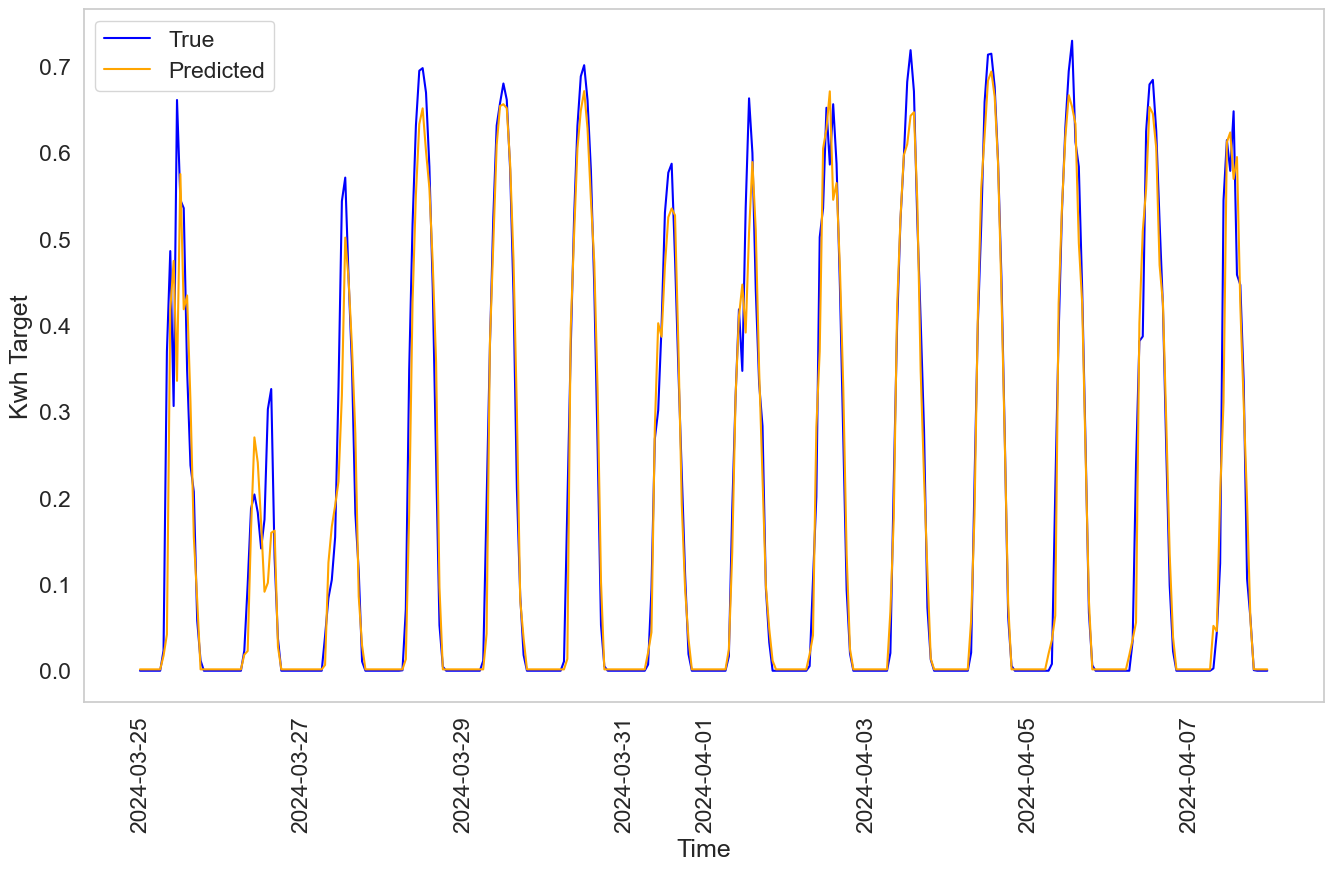

In [29]:
last_312_df = results_df.tail(336)
sns.set_style("whitegrid")

plt.figure(figsize=(16, 9))
sns.set_context("notebook", font_scale=1.5)
sns.lineplot(x=last_312_df.index, y=last_312_df['True'], label='True', color='blue')
sns.lineplot(x=last_312_df.index, y=last_312_df['Predicted'], label='Predicted', color='orange')
plt.xlabel('Time')
plt.ylabel('Kwh Target')
#plt.title('Predicted vs Actual Kwh Target')
plt.legend()
plt.xticks(rotation = 90)
plt.grid()
plt.show()

In [30]:
r2_score(results_df['Predicted'], results_df['True'])   #0.9483


0.9473063498130929